# Surrogate Models — Simulation Companion
Julian Hsu

This notebook backs the *Surrogate Models* slides. It simulates a **loyalty-program
pilot**: treatment `W` is randomized 50/50 and runs for 8 weeks, but the outcome of
record — **3-year customer spend** `Y` — will not exist until long after the
decision deadline. Three week-8 **surrogates** `S` (early spend, purchase
frequency, engagement) and a baseline covariate `X` (prior spend) are observed
right away, and a **historical cohort** (no program, `Y` on file) provides the
`S -> Y` bridge. The true 3-year effect is `tau = 5`.

We (1) build the **surrogate index** estimator step by step (Athey, Chetty,
Imbens & Kang 2019), (2) show its fragility when the surrogate bundle is too thin
or a **hidden channel** bypasses it, (3) swap the OLS bridge for a gradient-boosting
model to show stage 1 is ordinary supervised prediction, (4) compare **plug-in vs.
bootstrap** confidence intervals, and (5) run the Monte-Carlo study behind the bias
and coverage tables on the slides.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TAU = 5.0                            # true 3-year effect through the surrogates
A = np.array([10.0, 4.0, 2.0])       # surrogate intercepts
B = np.array([1.0, 0.8, 0.6])        # loadings on latent loyalty
C = np.array([2.0, 1.0, 1.0])        # effect of W on each surrogate
G = np.array([1.5, 1.0, 1.0])        # value of each surrogate in 3-year spend
S_SD = np.array([1.5, 1.0, 1.0])     # surrogate noise
SURROGATES = ["early spend", "purchase frequency", "engagement"]

## The data-generating process
Latent *loyalty* drives both the surrogates and (through them) 3-year spend:

* surrogates: $S_{ik} = a_k + b_k \cdot \text{loyalty}_i + c_k W_i + \epsilon_{ik}$
* outcome: $Y_i = 20 + \sum_k g_k S_{ik} + 2 X_i + \theta W_i + \epsilon_{iy}$

so the true effect is $\tau = \sum_k c_k g_k = 5$, plus any **direct effect**
$\theta$ that bypasses every surrogate (a surrogacy violation; `theta=0` unless
noted). The **experimental** sample has `W` randomized and `Y` unseen; the
**observational** (historical) sample predates the program (`W=0`) and has `Y` on
file, with the *same* structural `S -> Y` equation — comparability holds by
construction.

In [2]:
def gen(n, experimental=True, theta=0.0, sd_y=4.0, seed=None):
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, n)                         # baseline: prior spend (standardized)
    loyal = 0.5 * x + rng.normal(0, 1.0 if experimental else 1.15, n)
    w = rng.integers(0, 2, n).astype(float) if experimental else np.zeros(n)
    s = A + B * loyal[:, None] + C * w[:, None] + rng.normal(0, S_SD, (n, 3))
    y = 20.0 + s @ G + 2.0 * x + theta * w + rng.normal(0, sd_y, n)
    return x, w, s, y

## The estimator: three steps
1. **Learn the bridge** in the observational sample: $\hat{y}(s,x)=\hat E[Y\mid S,X]$ (here OLS).
2. **Score the pilot**: the surrogate index $\hat Y^{SI}_i = \hat y(S_i, X_i)$.
3. **Difference the index** between arms.

Two CIs for step 3: **plug-in** (a t-interval that pretends the index is data,
ignoring that the bridge was estimated) and a **bootstrap** that resamples *both*
samples and refits the bridge on every draw.

In [3]:
def fit_index(x_o, s_o, y_o, cols=(0, 1, 2)):
    """Step 1: OLS of Y on (S, X) in the observational sample."""
    Z = np.column_stack([np.ones_like(y_o), s_o[:, list(cols)], x_o])
    beta, *_ = np.linalg.lstsq(Z, y_o, rcond=None)
    return beta, cols


def score_index(fit, x_e, s_e):
    """Step 2: the surrogate index for each experimental unit."""
    beta, cols = fit
    Z = np.column_stack([np.ones(len(x_e)), s_e[:, list(cols)], x_e])
    return Z @ beta


def tau_si(fit, x_e, w_e, s_e):
    """Step 3: difference the index between arms."""
    idx = score_index(fit, x_e, s_e)
    return idx[w_e == 1].mean() - idx[w_e == 0].mean()


def plug_in_ci(fit, x_e, w_e, s_e):
    """t-interval on the index, as if it were observed data."""
    idx = score_index(fit, x_e, s_e)
    t, c = idx[w_e == 1], idx[w_e == 0]
    d = t.mean() - c.mean()
    se = np.sqrt(t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c))
    return d - 1.96 * se, d + 1.96 * se


def boot_ci(x_o, s_o, y_o, x_e, w_e, s_e, n_boot=200, seed=0):
    """Percentile bootstrap: resample both samples, refit the bridge each draw."""
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_boot):
        io = rng.integers(0, len(y_o), len(y_o))
        ie = rng.integers(0, len(x_e), len(x_e))
        vals.append(tau_si(fit_index(x_o[io], s_o[io], y_o[io]),
                           x_e[ie], w_e[ie], s_e[ie]))
    return np.percentile(vals, [2.5, 97.5])

## One pilot, side by side
Four estimates of the 3-year effect, all computable by month 3 except the oracle:

* **Short-run difference** — the arm gap in week-8 spend, reported as if it were the 3-year effect;
* **Single surrogate** — the index built from week-8 spend alone (Prentice-style);
* **Surrogate index** — the index from all three surrogates + the baseline covariate;
* **Oracle** — wait 3 years and difference actual `Y` (the benchmark the deadline forbids).

In [4]:
x_o, w_o, s_o, y_o = gen(10000, experimental=False, seed=42)
x_e, w_e, s_e, y_e = gen(2000, experimental=True, seed=43)

fit_full = fit_index(x_o, s_o, y_o)
estimates = {
    "Short-run difference (week-8 spend)": s_e[w_e == 1, 0].mean() - s_e[w_e == 0, 0].mean(),
    "Single surrogate": tau_si(fit_index(x_o, s_o, y_o, (0,)), x_e, w_e, s_e),
    "Surrogate index (all three)": tau_si(fit_full, x_e, w_e, s_e),
    "Oracle: wait 3 years": y_e[w_e == 1].mean() - y_e[w_e == 0].mean(),
}
lo, hi = boot_ci(x_o, s_o, y_o, x_e, w_e, s_e, seed=1)
print(pd.Series(estimates, name="estimate").round(2).to_string())
print(f"\ntruth: tau = {TAU};  bootstrap 95% CI for the surrogate index: [{lo:.2f}, {hi:.2f}]")

Short-run difference (week-8 spend)    2.02
Single surrogate                       4.25
Surrogate index (all three)            5.11
Oracle: wait 3 years                   4.89

truth: tau = 5.0;  bootstrap 95% CI for the surrogate index: [4.72, 5.56]


## The picture
Left: the historical cohort traces the `S -> Y` map (shown against one surrogate).
Right: in the pilot, treatment shifts the whole surrogate bundle; pushed through
the bridge, the index distribution shifts — the gap between arm means is
$\hat\tau_{SI}$.

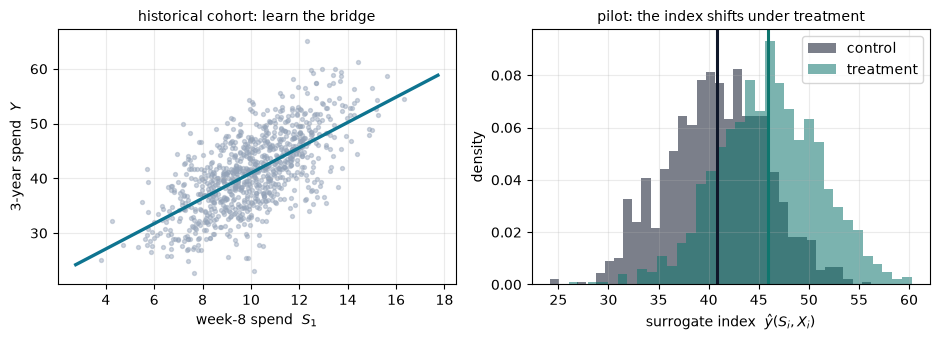

In [5]:
idx = score_index(fit_full, x_e, s_e)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.5))
ax = axes[0]
sub = np.random.default_rng(3).choice(len(y_o), 900, replace=False)
ax.scatter(s_o[sub, 0], y_o[sub], s=8, color="#94a3b8", alpha=0.45)
xs = np.linspace(s_o[:, 0].min(), s_o[:, 0].max(), 50)
ax.plot(xs, np.polyval(np.polyfit(s_o[:, 0], y_o, 1), xs), color="#0e7490", lw=2.4)
ax.set_xlabel("week-8 spend  $S_1$"); ax.set_ylabel("3-year spend  $Y$")
ax.set_title("historical cohort: learn the bridge", fontsize=10); ax.grid(alpha=.25)
ax = axes[1]
for arm, col, lab in ((0, "#0f172a", "control"), (1, "#0f766e", "treatment")):
    ax.hist(idx[w_e == arm], bins=35, density=True, alpha=0.55, color=col, label=lab)
    ax.axvline(idx[w_e == arm].mean(), color=col, lw=2.2)
ax.set_xlabel("surrogate index  $\\hat{y}(S_i, X_i)$"); ax.set_ylabel("density")
ax.set_title("pilot: the index shifts under treatment", fontsize=10)
ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## One surrogate is fragile
Each surrogate alone carries only part of the treatment's footprint, so a thin
index understates the effect. The estimate climbs toward the truth as the bundle
fills out — the case for logging **many** surrogates.

In [6]:
subsets = {"S1 only (week-8 spend)": (0,), "S1, S2": (0, 1), "S1, S2, S3 (full set)": (0, 1, 2)}
rows = {name: [] for name in subsets}
for r in range(200):
    x_o, w_o, s_o, y_o = gen(10000, experimental=False, seed=1000 + r)
    x_e, w_e, s_e, y_e = gen(2000, experimental=True, seed=5000 + r)
    for name, cols in subsets.items():
        rows[name].append(tau_si(fit_index(x_o, s_o, y_o, cols), x_e, w_e, s_e))
tbl = pd.DataFrame({name: {"mean estimate": np.mean(v), "bias": np.mean(v) - TAU}
                    for name, v in rows.items()}).T
print(f"truth: tau = {TAU}\n")
print(tbl.round(2).to_string())

truth: tau = 5.0

                        mean estimate  bias
S1 only (week-8 spend)           4.04 -0.96
S1, S2                           4.55 -0.45
S1, S2, S3 (full set)            4.99 -0.01


## A hidden channel: surrogacy violated
Add a direct effect `theta` of the treatment on `Y` that bypasses every surrogate.
The index misses **exactly** that channel — bias $= -\theta$ — and nothing in the
data warns you: the fit of the bridge, the CIs, everything looks fine.

In [7]:
rows = []
for th in [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]:
    vals = []
    for r in range(200):
        x_o, w_o, s_o, y_o = gen(10000, experimental=False, seed=2000 + r)
        x_e, w_e, s_e, y_e = gen(2000, experimental=True, theta=th, seed=8000 + r)
        vals.append(tau_si(fit_index(x_o, s_o, y_o), x_e, w_e, s_e))
    rows.append({"theta (bypass)": th, "true effect": TAU + th,
                 "mean SI estimate": np.mean(vals), "bias": np.mean(vals) - TAU - th})
print(pd.DataFrame(rows).round(2).to_string(index=False))

 theta (bypass)  true effect  mean SI estimate  bias
            0.0          5.0               5.0   0.0
            0.5          5.5               5.0  -0.5
            1.0          6.0               5.0  -1.0
            1.5          6.5               5.0  -1.5
            2.0          7.0               5.0  -2.0
            2.5          7.5               5.0  -2.5


## The bridge is just prediction — use any ML
Stage 1 never needs a causal interpretation, so any supervised learner works.
To see it matter, make the true `S -> Y` map **quadratic** in the surrogate
bundle: an OLS bridge fit on the (lower-index) historical cohort extrapolates its
tangent line into the treated arm's (higher-index) region and misses the
curvature; a gradient-boosting bridge follows the curve. The truth is computed
from the structural model by counterfactual simulation.

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor

def gen_quad(n, experimental=True, seed=None):
    """Same design, but Y is quadratic in the surrogate bundle v = S @ G."""
    rng = np.random.default_rng(seed)
    x = rng.normal(0, 1, n)
    loyal = 0.5 * x + rng.normal(0, 1.0 if experimental else 1.15, n)
    w = rng.integers(0, 2, n).astype(float) if experimental else np.zeros(n)
    s = A + B * loyal[:, None] + C * w[:, None] + rng.normal(0, S_SD, (n, 3))
    y = 20.0 + 0.02 * (s @ G) ** 2 + 2.0 * x + rng.normal(0, 4.0, n)
    return x, w, s, y

# truth by counterfactual simulation: same units, S built under w=1 vs w=0
rng = np.random.default_rng(0)
n = 1_000_000
x = rng.normal(0, 1, n); loyal = 0.5 * x + rng.normal(0, 1.0, n)
eps = rng.normal(0, S_SD, (n, 3))
s1 = A + B * loyal[:, None] + C + eps; s0 = A + B * loyal[:, None] + eps
tau_quad = (0.02 * (s1 @ G) ** 2 - 0.02 * (s0 @ G) ** 2).mean()

res = {"OLS bridge": [], "Gradient boosting bridge": []}
for r in range(100):
    x_o, w_o, s_o, y_o = gen_quad(10000, experimental=False, seed=4000 + r)
    x_e, w_e, s_e, y_e = gen_quad(2000, experimental=True, seed=40000 + r)
    res["OLS bridge"].append(tau_si(fit_index(x_o, s_o, y_o), x_e, w_e, s_e))
    gbm = HistGradientBoostingRegressor(max_iter=200, random_state=0)
    gbm.fit(np.column_stack([s_o, x_o]), y_o)
    idx_g = gbm.predict(np.column_stack([s_e, x_e]))
    res["Gradient boosting bridge"].append(idx_g[w_e == 1].mean() - idx_g[w_e == 0].mean())

tbl = pd.DataFrame({k: {"mean estimate": np.mean(v), "bias": np.mean(v) - tau_quad}
                    for k, v in res.items()}).T
print(f"quadratic S->Y map; truth by simulation: tau = {tau_quad:.2f}\n")
print(tbl.round(2).to_string())

quadratic S->Y map; truth by simulation: tau = 4.70

                          mean estimate  bias
OLS bridge                         4.22 -0.48
Gradient boosting bridge           4.70  0.00


## Inference: carry the first-stage uncertainty
The index is a *prediction*, not data — the bridge $\hat y(\cdot)$ has sampling
noise of its own. With a large historical cohort the plug-in t-interval is nearly
fine; with a thin one it ignores real uncertainty and **undercovers**. The
bootstrap (refit the bridge on every draw) restores most of it. These are the
coverage numbers on the slides.

In [9]:
def coverage(n_obs, R=500, n_exp=2000):
    cov_plug, cov_boot = [], []
    for r in range(R):
        x_o, w_o, s_o, y_o = gen(n_obs, experimental=False, seed=2000 + r)
        x_e, w_e, s_e, y_e = gen(n_exp, experimental=True, seed=200000 + r)
        fit = fit_index(x_o, s_o, y_o)
        lo, hi = plug_in_ci(fit, x_e, w_e, s_e)
        cov_plug.append(lo <= TAU <= hi)
        lo, hi = boot_ci(x_o, s_o, y_o, x_e, w_e, s_e, seed=r)
        cov_boot.append(lo <= TAU <= hi)
    return np.mean(cov_plug), np.mean(cov_boot)

cov = {f"n_obs = {n:,}": dict(zip(["Plug-in", "Bootstrap (both stages)"], coverage(n)))
       for n in (10000, 500)}
print("coverage of nominal 95% CIs for the surrogate index (valid surrogacy):\n")
print(pd.DataFrame(cov).round(2).to_string())

coverage of nominal 95% CIs for the surrogate index (valid surrogacy):

                         n_obs = 10,000  n_obs = 500
Plug-in                            0.95         0.85
Bootstrap (both stages)            0.94         0.91


## Monte-Carlo study: bias
500 simulated pilots per scenario. **Valid**: the treatment reaches `Y` only
through the three surrogates (`tau = 5`). **Hidden channel**: an extra
`theta = 1.5` bypasses them (`tau = 6.5`). These are the numbers on the slides.
Note the standard deviations: the surrogate index is *more precise than waiting*
— it averages away the part of `Y` the surrogates can't predict.

In [10]:
def mc_bias(theta, R=500, n_exp=2000, n_obs=10000):
    truth = TAU + theta
    rows = {k: [] for k in ["Short-run difference", "Single surrogate",
                            "Surrogate index", "Oracle (wait 3 years)"]}
    for r in range(R):
        x_o, w_o, s_o, y_o = gen(n_obs, experimental=False, seed=1000 + r)
        x_e, w_e, s_e, y_e = gen(n_exp, experimental=True, theta=theta, seed=100000 + r)
        rows["Short-run difference"].append(s_e[w_e == 1, 0].mean() - s_e[w_e == 0, 0].mean())
        rows["Single surrogate"].append(tau_si(fit_index(x_o, s_o, y_o, (0,)), x_e, w_e, s_e))
        rows["Surrogate index"].append(tau_si(fit_index(x_o, s_o, y_o), x_e, w_e, s_e))
        rows["Oracle (wait 3 years)"].append(y_e[w_e == 1].mean() - y_e[w_e == 0].mean())
    return ({k: np.mean(v) - truth for k, v in rows.items()},
            {k: np.std(v) for k, v in rows.items()})

bias_v, sd_v = mc_bias(0.0)
bias_h, sd_h = mc_bias(1.5)
tbl = pd.DataFrame({"bias (valid, tau=5)": bias_v, "bias (hidden channel, tau=6.5)": bias_h,
                    "SD of estimate": sd_v})
print(tbl.round(2).to_string())

                       bias (valid, tau=5)  bias (hidden channel, tau=6.5)  SD of estimate
Short-run difference                 -3.00                           -4.50            0.08
Single surrogate                     -0.98                           -2.48            0.24
Surrogate index                      -0.01                           -1.51            0.25
Oracle (wait 3 years)                 0.00                            0.00            0.31


## Takeaways
* The surrogate index chains the two things observable by the deadline — the
  experiment's `W -> S` and history's `S -> Y` — and recovers the long-run
  effect **when surrogacy and comparability hold**.
* A **thin bundle understates**; richness is the defense. A **hidden channel
  biases by exactly the bypassed effect**, silently — back-test the index on
  finished experiments whose long-run outcomes have matured.
* Stage 1 is ordinary prediction: when the `S -> Y` map is curved, a flexible
  learner fixes what OLS misses. Never interpret the bridge's coefficients
  causally.
* The index is a prediction, not data: with a thin historical sample, plug-in
  CIs undercover — bootstrap both stages (or use the influence-function SEs of
  Athey et al. 2019).
* Precision bonus: the index can beat waiting for `Y` — it filters out the
  outcome noise the surrogates don't predict. Precision is not validity.